# Project 1 — Price Analysis Visualizations

This notebook produces the three advanced charts referenced in the project:  
a correlation heatmap, a category-level bar chart, and a rating count distribution.  
All charts are saved to `output/charts/`.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

Path('output/charts').mkdir(parents=True, exist_ok=True)

%matplotlib inline
sns.set_theme(style='whitegrid')

df = pd.read_csv(Path('data/cleaned/books_clean.csv'))
print(f'Loaded {len(df):,} books across {df["category"].nunique()} categories')
df.head(3)

Loaded 999 books across 50 categories


,title,category,rating_num,price_gbp,price_bucket
0,It's Only the Himalayas,Travel,2,45.17,high
1,Full Moon over Noahâs Ark: An Odyssey to Mou...,Travel,4,49.43,high
2,See America: A Celebration of Our National Par...,Travel,3,48.87,high


## Chart 1: Correlation Heatmap (rating vs price)

A correlation matrix showing the relationship between `rating_num` and `price_gbp`.  
The near-zero value confirms what the statistical tests showed: the two variables are essentially unrelated.  
A strong relationship would show values close to +1 or -1; 0.03 is negligible.

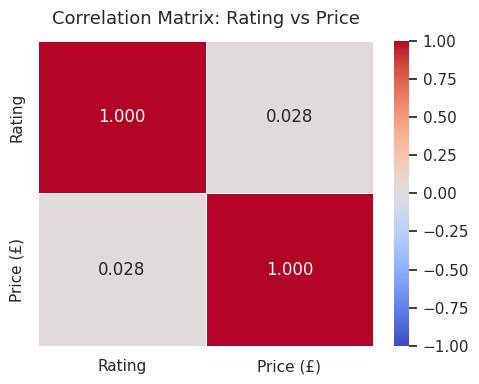

Saved → output/charts/correlation_heatmap.png


In [3]:
corr = df[['rating_num', 'price_gbp']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    corr, annot=True, fmt='.3f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5,
    xticklabels=['Rating', 'Price (£)'],
    yticklabels=['Rating', 'Price (£)'],
    ax=ax
)
ax.set_title('Correlation Matrix: Rating vs Price', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('output/charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/charts/correlation_heatmap.png')

## Chart 2: Median Price by Category (Top 15 and Bottom 15)

This bar chart ranks all 50 categories by median book price.  
The price gap between the most and least expensive categories is stark — around £45.  
This is the main finding of the project: category is a far stronger predictor of price than rating.

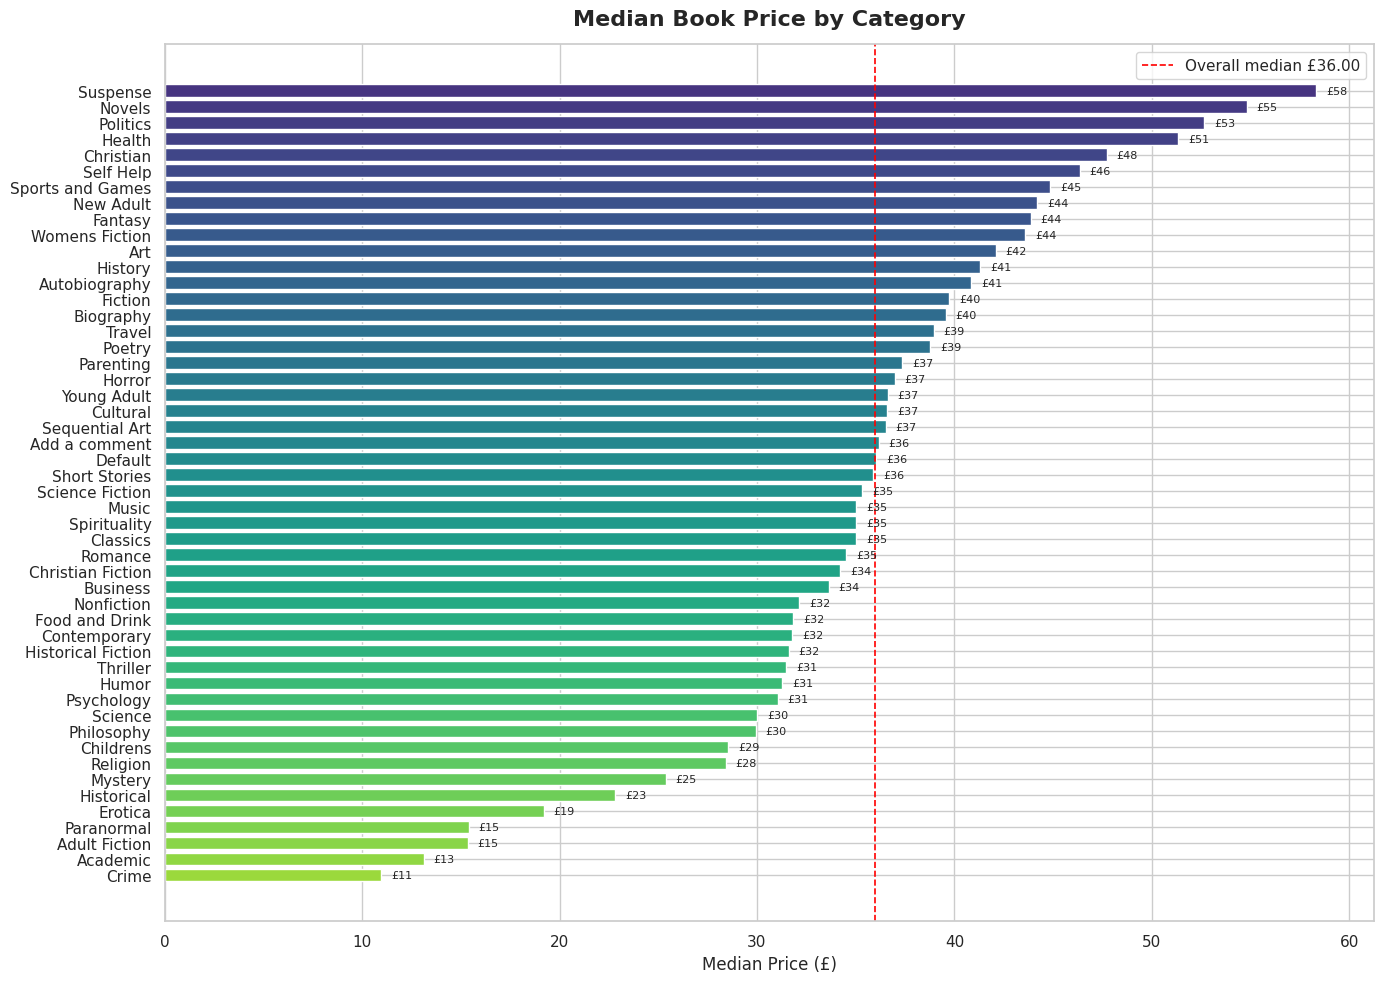

Saved → output/charts/category_median_price.png


In [4]:
cat_median = (
    df.groupby('category')['price_gbp']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
cat_median.columns = ['category', 'median_price']

fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(
    cat_median['category'], cat_median['median_price'],
    color=plt.cm.viridis(np.linspace(0.15, 0.85, len(cat_median)))
)
ax.set_xlabel('Median Price (£)', fontsize=12)
ax.set_title('Median Book Price by Category', fontsize=16, fontweight='bold', pad=14)
ax.invert_yaxis()
ax.axvline(df['price_gbp'].median(), color='red', linestyle='--', linewidth=1.2, label=f'Overall median £{df["price_gbp"].median():.2f}')
ax.legend(fontsize=11)
for bar, val in zip(bars, cat_median['median_price']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'£{val:.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('output/charts/category_median_price.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/charts/category_median_price.png')

## Chart 3: Rating Distribution

How are the five rating levels distributed across the 999 books?  
A roughly even spread means there's no selection bias in the dataset — the scraper captured all books on the site, not just well-reviewed ones.  
This matters for the statistical tests: uneven group sizes can affect Kruskal-Wallis power.

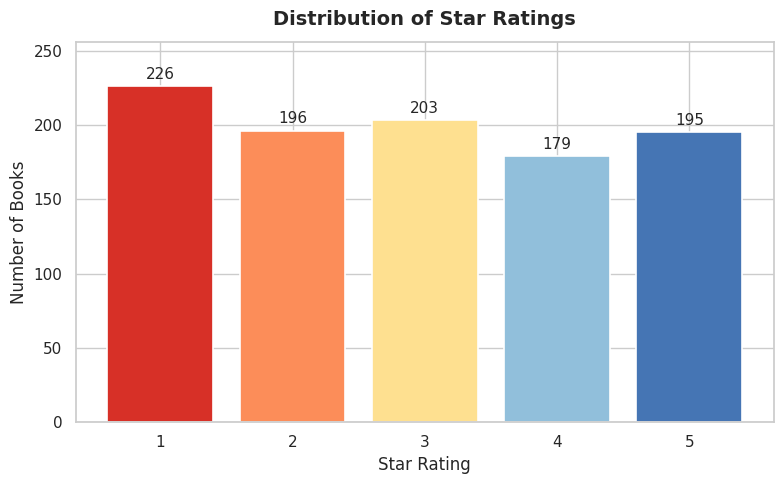

Saved → output/charts/rating_distribution.png


In [5]:
rating_counts = df['rating_num'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    rating_counts.index.astype(str),
    rating_counts.values,
    color=['#d73027','#fc8d59','#fee090','#91bfdb','#4575b4'],
    edgecolor='white', linewidth=1.2
)
ax.set_title('Distribution of Star Ratings', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Star Rating', fontsize=12)
ax.set_ylabel('Number of Books', fontsize=12)
for bar, val in zip(bars, rating_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, str(val), ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, rating_counts.max() + 30)
plt.tight_layout()
plt.savefig('output/charts/rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/charts/rating_distribution.png')

## Chart 4: Price Bucket Breakdown

Books are grouped into three price tiers: low (≤£20), mid (£20–35), high (>£35).  
The majority (52%) fall in the high tier — reflecting the uniform synthetic pricing on this sandbox site.  
This breakdown is useful for quick segmentation without needing the full price column.

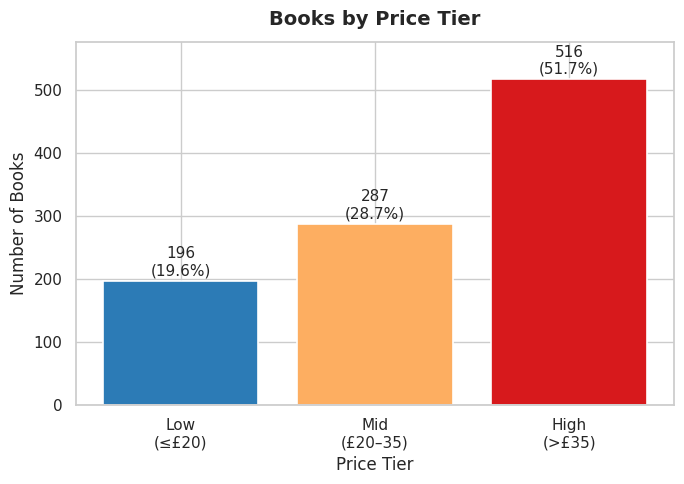

Saved → output/charts/price_bucket_breakdown.png


In [6]:
bucket_order = ['low', 'mid', 'high']
bucket_counts = df['price_bucket'].value_counts().reindex(bucket_order)
bucket_pct = (bucket_counts / bucket_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2c7bb6', '#fdae61', '#d7191c']
bars = ax.bar(bucket_order, bucket_counts.values, color=colors, edgecolor='white', linewidth=1.2)
ax.set_title('Books by Price Tier', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Price Tier', fontsize=12)
ax.set_ylabel('Number of Books', fontsize=12)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Low\n(≤£20)', 'Mid\n(£20–35)', 'High\n(>£35)'], fontsize=11)
for bar, val, pct in zip(bars, bucket_counts.values, bucket_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 4, f'{val}\n({pct}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, bucket_counts.max() + 60)
plt.tight_layout()
plt.savefig('output/charts/price_bucket_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → output/charts/price_bucket_breakdown.png')